# Inference

In [ ]:
import torch
from PIL import Image

import datasets.transforms as T  # noqa: N812
from datasets import build_dataset
from models import build_DABDETR
from util import box_ops
from util.slconfig import SLConfig
from util.visualizer import COCOVisualizer


# Load

In [ ]:
model_config_path = "/home/emanuele/Scrivania/Lavoro/Github/Hi-DAB-DETR/My/output_dir/config.json"
model_checkpoint_path = "/home/emanuele/Scrivania/Lavoro/Github/Hi-DAB-DETR/My/output_dir/checkpoint.pth"

args = SLConfig.fromfile(model_config_path)
model, criterion, postprocessors = build_DABDETR(args)
checkpoint = torch.load(model_checkpoint_path, map_location='cpu',
                        weights_only=False)
model.load_state_dict(checkpoint['model'])

/home/emanuele/Scrivania/Lavoro/Github/Hi-DAB-DETR/venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/emanuele/Scrivania/Lavoro/Github/Hi-DAB-DETR/venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<All keys matched successfully>

# Inference from Dataloader

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


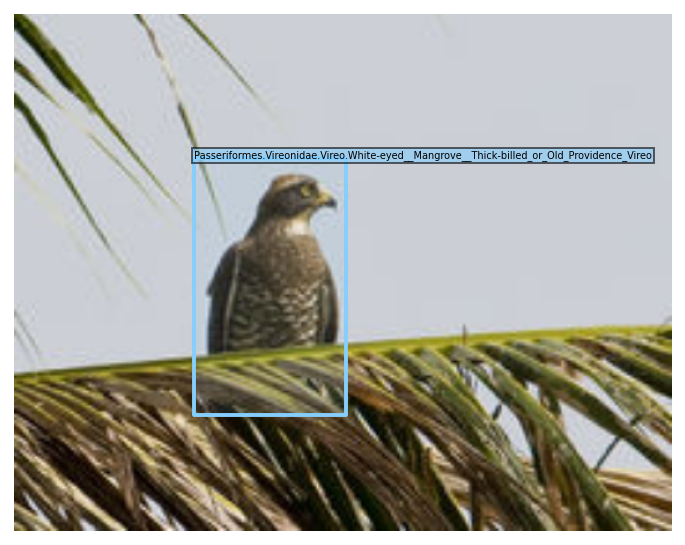

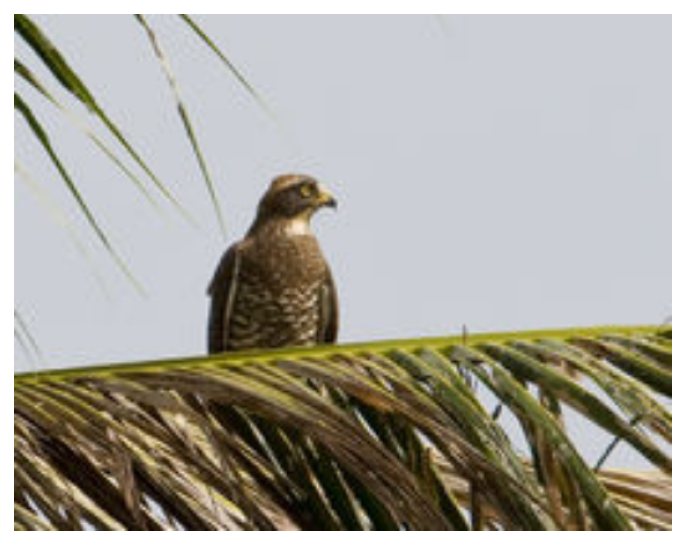

In [17]:
# Load dataset
dataset_val = build_dataset(image_set='val', args=args)
cocojs = dataset_val.coco.dataset
id2name = {item['id']: item['name'] for item in cocojs['categories']}

# Choose one example
image, targets = dataset_val[0]

# visualize gt
box_label = [id2name[int(item)] for item in targets['labels']]
gt_dict = {
    'boxes': targets['boxes'],
    'image_id': targets['image_id'],
    'size': targets['size'],
    'box_label': box_label,
}
vslzr = COCOVisualizer()
vslzr.visualize(image, gt_dict, savedir=None)

# Predict
output = model(image[None])
output = postprocessors['bbox'](output, torch.Tensor([[1.0, 1.0]]))[0]

# Visualize prediction
thershold = 0.4 # set a thershold

scores = output['scores']
labels = output['labels']
boxes = box_ops.box_xyxy_to_cxcywh(output['boxes'])
select_mask = scores > thershold

box_label = [id2name[int(item)] for item in labels[select_mask]]
pred_dict = {
    'boxes': boxes[select_mask],
    'size': targets['size'],
    'box_label': box_label
}
vslzr.visualize(image, pred_dict, savedir=None)

# Inference from custom image

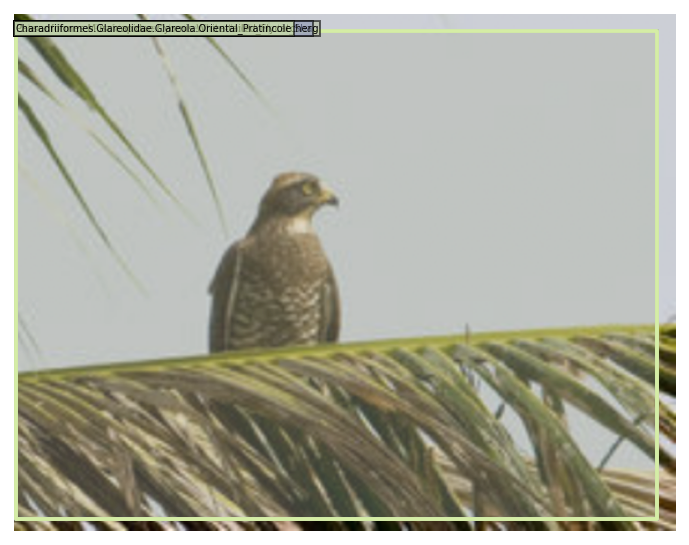

In [ ]:
# Load image
image = Image.open("My/example.png").convert("RGB")

# WARNING change the scale of random size accordingly to train.
# transform images
transform = T.Compose([
    T.RandomResize([800], max_size=1333),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
image, _ = transform(image, None)


# predict images
output = model(image[None])
output = postprocessors['bbox'](output, torch.Tensor([[1.0, 1.0]]))[0]


# visualize outputs
thershold = 0.035 # set a thershold

scores = output['scores']
labels = output['labels']
boxes = box_ops.box_xyxy_to_cxcywh(output['boxes'])
select_mask = scores > thershold

box_label = [id2name[int(item)] for item in labels[select_mask]]
pred_dict = {
    'boxes': boxes[select_mask],
    'size': torch.Tensor([image.shape[1], image.shape[2]]),
    'box_label': box_label
}
vslzr.visualize(image, pred_dict, savedir=None)